In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import numpy as np
from sklearn.decomposition import PCA

# Problem - 1 : Training an autoencoder as a 2D feature generator and displaying CIFAR10 dataset's features

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(True),
            nn.Linear(512, 128),
            nn.ReLU(True),
            nn.Linear(128, 2)  
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(True),
            nn.Linear(128, 512),
            nn.ReLU(True),
            nn.Linear(512, 3 * 32 * 32),
            nn.Sigmoid(),
            nn.Unflatten(1, (3, 32, 32))
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [5]:
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/20], Loss: 0.0399
Epoch [2/20], Loss: 0.0369
Epoch [3/20], Loss: 0.0368
Epoch [4/20], Loss: 0.0364
Epoch [5/20], Loss: 0.0361
Epoch [6/20], Loss: 0.0356
Epoch [7/20], Loss: 0.0355
Epoch [8/20], Loss: 0.0354
Epoch [9/20], Loss: 0.0352
Epoch [10/20], Loss: 0.0353
Epoch [11/20], Loss: 0.0350
Epoch [12/20], Loss: 0.0351
Epoch [13/20], Loss: 0.0349
Epoch [14/20], Loss: 0.0349
Epoch [15/20], Loss: 0.0347
Epoch [16/20], Loss: 0.0347
Epoch [17/20], Loss: 0.0345
Epoch [18/20], Loss: 0.0345
Epoch [19/20], Loss: 0.0344
Epoch [20/20], Loss: 0.0343


In [6]:
model.eval()
features = []
labels = []
with torch.no_grad():
    for images, lbls in train_loader:
        images = images.to(device)
        _, z = model(images)
        features.append(z.cpu().numpy())
        labels.append(lbls.numpy())

features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

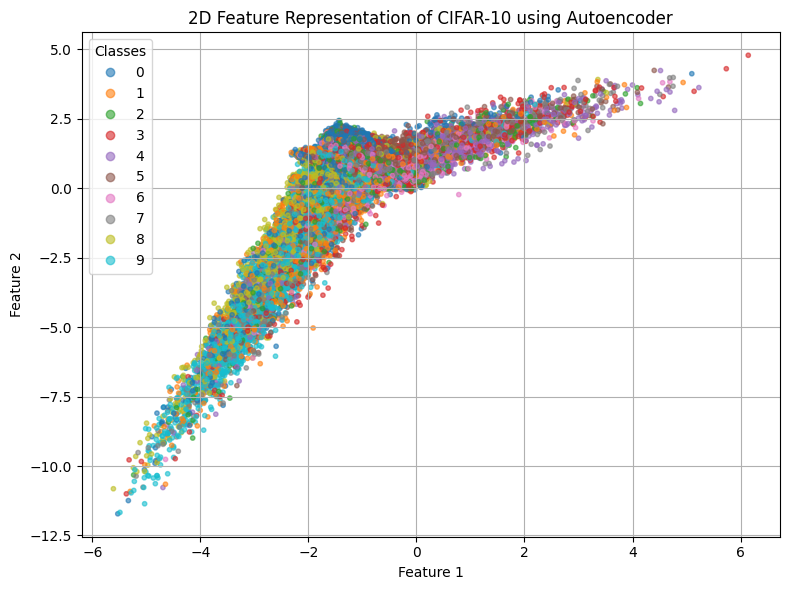

In [7]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
plt.legend(*scatter.legend_elements(), title="Classes", loc="best")
plt.title("2D Feature Representation of CIFAR-10 using Autoencoder")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# Problem - 2 : Comparing autoencoder generated features with features extracted by a pre-trained CNN and reduced by dimension reduction techniques like PCA, t-SNE.

In [9]:
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")


Epoch [1/20], Loss: 0.0345
Epoch [2/20], Loss: 0.0345
Epoch [3/20], Loss: 0.0345
Epoch [4/20], Loss: 0.0346
Epoch [5/20], Loss: 0.0347
Epoch [6/20], Loss: 0.0343
Epoch [7/20], Loss: 0.0344
Epoch [8/20], Loss: 0.0344
Epoch [9/20], Loss: 0.0343
Epoch [10/20], Loss: 0.0343
Epoch [11/20], Loss: 0.0343
Epoch [12/20], Loss: 0.0340
Epoch [13/20], Loss: 0.0340
Epoch [14/20], Loss: 0.0341
Epoch [15/20], Loss: 0.0346
Epoch [16/20], Loss: 0.0344
Epoch [17/20], Loss: 0.0344
Epoch [18/20], Loss: 0.0338
Epoch [19/20], Loss: 0.0342
Epoch [20/20], Loss: 0.0340


In [10]:
model.eval()
auto_features = []
pca_features = []
tsne_features = []
labels = []

resnet = torchvision.models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet.eval().to(device)

with torch.no_grad():
    for images, lbls in train_loader:
        images = images.to(device)
        _, z_auto = model(images)
        auto_features.append(z_auto.cpu().numpy())

        cnn_feats = resnet(images).cpu().numpy()
        pca_feats = PCA(n_components=2).fit_transform(cnn_feats)
        tsne_feats = TSNE(n_components=2, perplexity=30, n_iter=300).fit_transform(cnn_feats)

        pca_features.append(pca_feats)
        tsne_features.append(tsne_feats)
        labels.append(lbls.numpy())

auto_features = np.concatenate(auto_features, axis=0)
pca_features = np.concatenate(pca_features, axis=0)
tsne_features = np.concatenate(tsne_features, axis=0)
labels = np.concatenate(labels, axis=0)

/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/cse/.local/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/cse/.local/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  wa

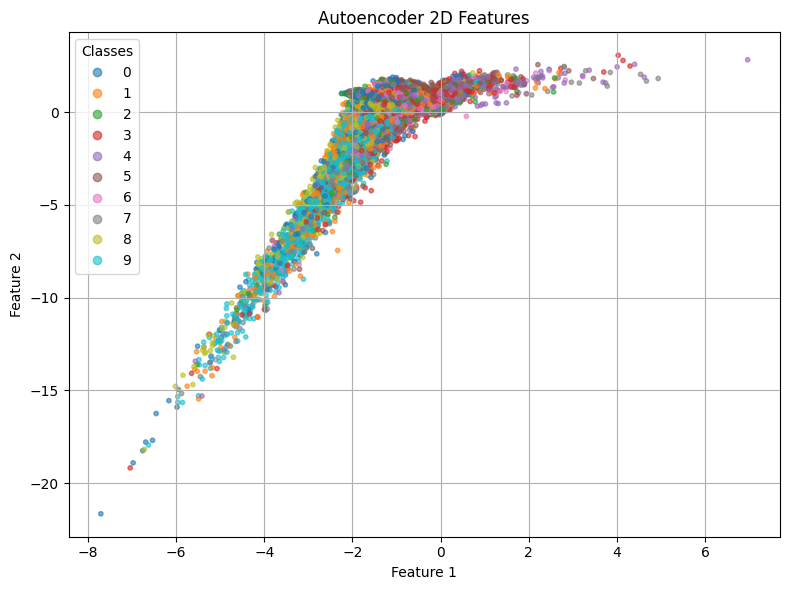

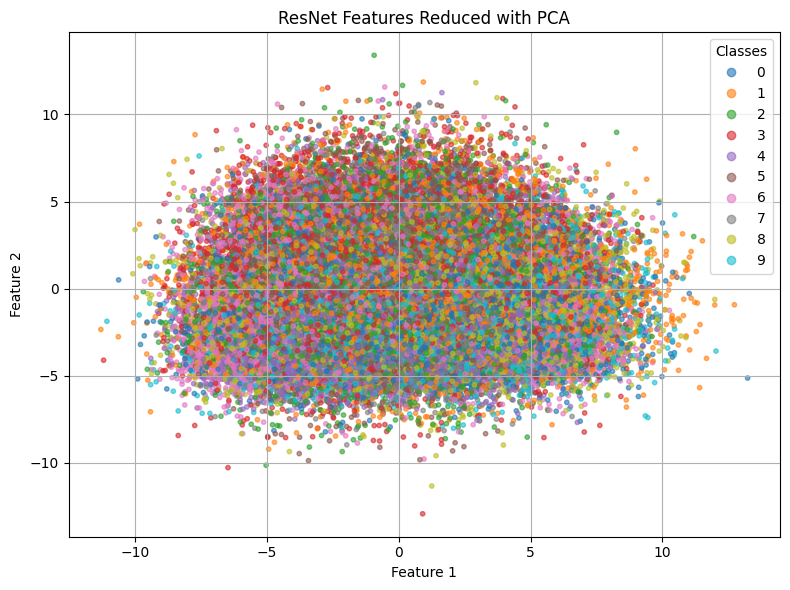

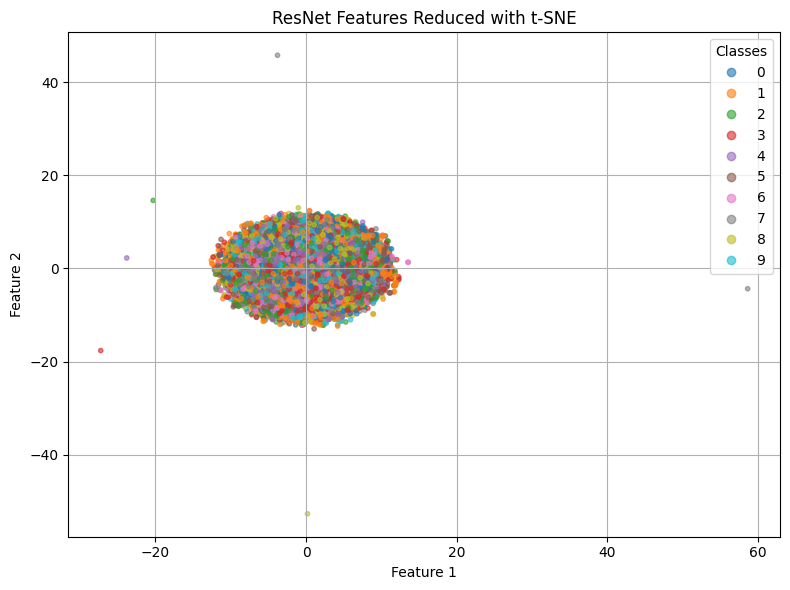

In [ ]:

def plot_features(features, labels, title):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.legend(*scatter.legend_elements(), title="Classes", loc="best")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ----------- Plot Results -----------
plot_features(auto_features, labels, "Autoencoder 2D Features")
plot_features(pca_features, labels, "ResNet Features Reduced with PCA")
plot_features(tsne_features, labels, "ResNet Features Reduced with t-SNE")


# Problem - 3 : Training Denoising Auto-Encoder

In [12]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(True),
            nn.Linear(512, 128),
            nn.ReLU(True),
            nn.Linear(128, 2)  
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(True),
            nn.Linear(128, 512),
            nn.ReLU(True),
            nn.Linear(512, 3 * 32 * 32),
            nn.Sigmoid(),
            nn.Unflatten(1, (3, 32, 32))
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [14]:
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = images + 0.3 * torch.randn_like(images)
        noisy_images = torch.clamp(noisy_images, 0., 1.)

        outputs, _ = model(noisy_images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/20], Loss: 0.0409
Epoch [2/20], Loss: 0.0371
Epoch [3/20], Loss: 0.0369
Epoch [4/20], Loss: 0.0368
Epoch [5/20], Loss: 0.0367
Epoch [6/20], Loss: 0.0364
Epoch [7/20], Loss: 0.0360
Epoch [8/20], Loss: 0.0357
Epoch [9/20], Loss: 0.0353
Epoch [10/20], Loss: 0.0353
Epoch [11/20], Loss: 0.0352
Epoch [12/20], Loss: 0.0352
Epoch [13/20], Loss: 0.0350
Epoch [14/20], Loss: 0.0349
Epoch [15/20], Loss: 0.0351
Epoch [16/20], Loss: 0.0350
Epoch [17/20], Loss: 0.0348
Epoch [18/20], Loss: 0.0345
Epoch [19/20], Loss: 0.0346
Epoch [20/20], Loss: 0.0345


In [15]:
model.eval()
auto_features = []
pca_features = []
tsne_features = []
labels = []

resnet = torchvision.models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet.eval().to(device)

with torch.no_grad():
    for images, lbls in train_loader:
        images = images.to(device)
        noisy_images = images + 0.3 * torch.randn_like(images)
        noisy_images = torch.clamp(noisy_images, 0., 1.)

        _, z_auto = model(noisy_images)
        auto_features.append(z_auto.cpu().numpy())

        cnn_feats = resnet(images).cpu().numpy()
        pca_feats = PCA(n_components=2).fit_transform(cnn_feats)
        tsne_feats = TSNE(n_components=2, perplexity=30, n_iter=300).fit_transform(cnn_feats)

        pca_features.append(pca_feats)
        tsne_features.append(tsne_feats)
        labels.append(lbls.numpy())

auto_features = np.concatenate(auto_features, axis=0)
pca_features = np.concatenate(pca_features, axis=0)
tsne_features = np.concatenate(tsne_features, axis=0)
labels = np.concatenate(labels, axis=0)

/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/cse/.local/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/cse/.local/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  wa

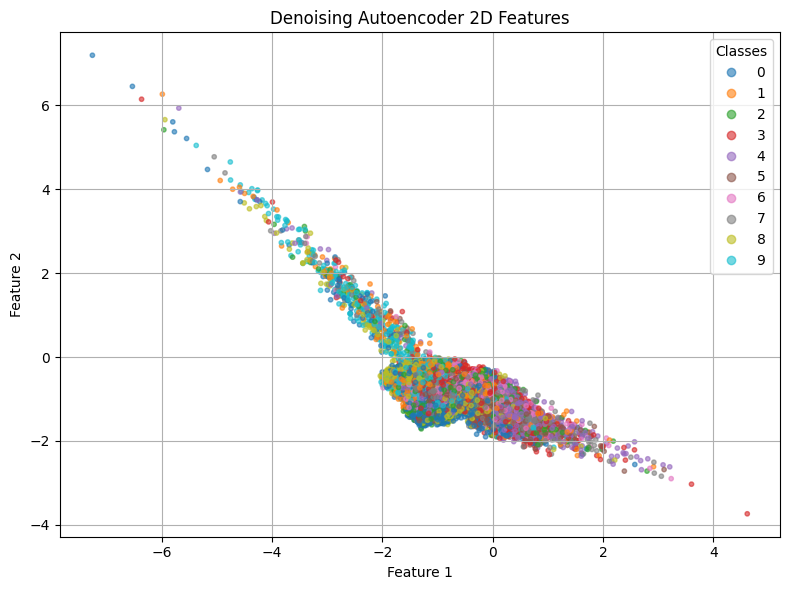

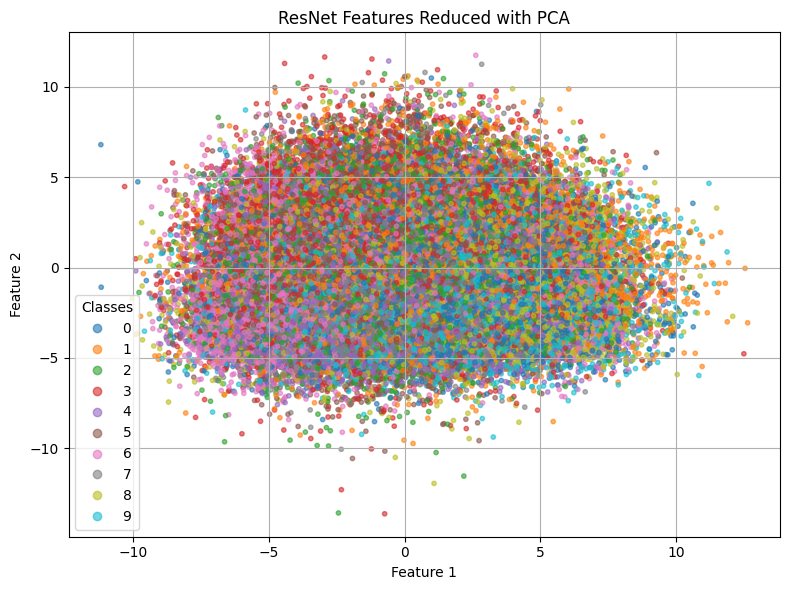

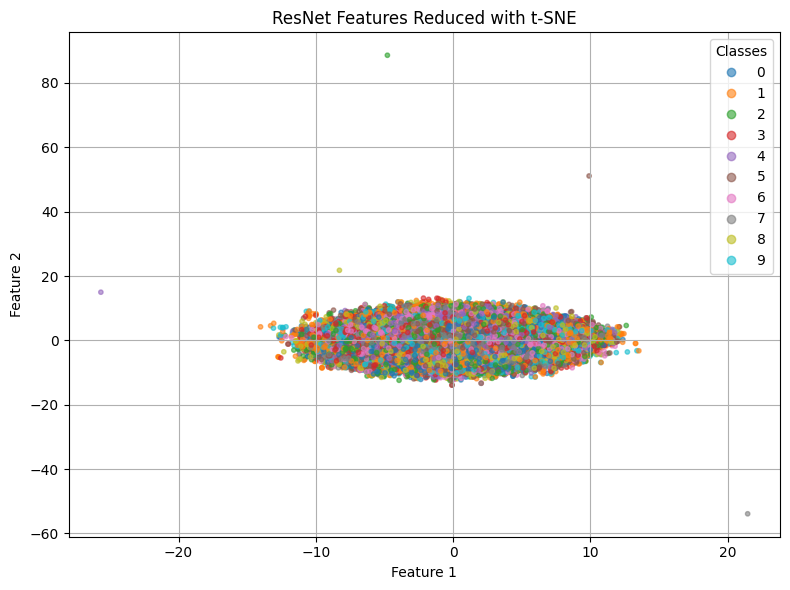

In [16]:
def plot_features(features, labels, title):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.legend(*scatter.legend_elements(), title="Classes", loc="best")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ----------- Plot Results -----------
plot_features(auto_features, labels, "Denoising Autoencoder 2D Features")
plot_features(pca_features, labels, "ResNet Features Reduced with PCA")
plot_features(tsne_features, labels, "ResNet Features Reduced with t-SNE")

# Problem- 4 : Training a CNN based CIFAR-10 classifier without any single-image data augmentation techniques

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [20]:
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {100.*correct/total:.2f}%")

Epoch 1, Loss: 1.8037, Train Acc: 32.10%
Epoch 2, Loss: 1.5360, Train Acc: 43.56%
Epoch 3, Loss: 1.4215, Train Acc: 48.71%
Epoch 4, Loss: 1.3423, Train Acc: 51.40%
Epoch 5, Loss: 1.2796, Train Acc: 54.15%
Epoch 6, Loss: 1.2255, Train Acc: 56.24%
Epoch 7, Loss: 1.1762, Train Acc: 58.29%
Epoch 8, Loss: 1.1390, Train Acc: 59.34%
Epoch 9, Loss: 1.1004, Train Acc: 60.94%
Epoch 10, Loss: 1.0664, Train Acc: 62.14%


In [21]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100.*correct/total:.2f}%")

Test Accuracy: 62.03%


# Problem - 5 : Training a CNN based CIFAR-10 classifier with a single/multiple single-image data augmentation techniques

In [22]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [23]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {100.*correct/total:.2f}%")

Epoch 1, Loss: 1.7592, Train Acc: 34.97%
Epoch 2, Loss: 1.4489, Train Acc: 47.51%
Epoch 3, Loss: 1.2902, Train Acc: 53.91%
Epoch 4, Loss: 1.1925, Train Acc: 57.68%
Epoch 5, Loss: 1.1350, Train Acc: 59.74%
Epoch 6, Loss: 1.0772, Train Acc: 62.05%
Epoch 7, Loss: 1.0315, Train Acc: 63.64%
Epoch 8, Loss: 0.9974, Train Acc: 65.20%
Epoch 9, Loss: 0.9711, Train Acc: 65.84%
Epoch 10, Loss: 0.9483, Train Acc: 66.57%


In [26]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100.*correct/total:.2f}%")

Test Accuracy: 65.72%
